In [3]:
from datasets import load_dataset

dataset = load_dataset("ccdv/arxiv-classification")
print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 28388
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
})
{'text': 'Constrained Submodular Maximization via a\nNon-symmetric Technique\n\narXiv:1611.03253v1 [cs.DS] 10 Nov 2016\n\nNiv Buchbinder∗\n\nMoran Feldman†\n\nNovember 11, 2016\n\nAbstract\nThe study of combinatorial optimization problems with a submodular objective has attracted\nmuch attention in recent years. Such problems are important in both theory and practice because\ntheir objective functions are very general. Obtaining further improvements for many submodular\nmaximization problems boils down to finding better algorithms for optimizing a relaxation of\nthem known as the multilinear extension.\nIn this work we present an algorithm for optimizing the multilinear relaxation whose guarantee improves

In [4]:
import pandas as pd

df = pd.DataFrame(dataset["train"])
print(f"Total papers: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total papers: 28388
Columns: ['text', 'label']


,text,label
0,Constrained Submodular Maximization via a\nNon...,8
1,Self Organizing Maps Whose Topologies Can Be L...,9
2,Robust Satisfaction of Temporal Logic Specific...,3
3,BATCHED QR AND SVD ALGORITHMS ON GPUS WITH APP...,8
4,Analytical and simplified models for dynamic a...,5


Number of categories: 11


<Axes: title={'center': 'Papers per Category'}, xlabel='label'>

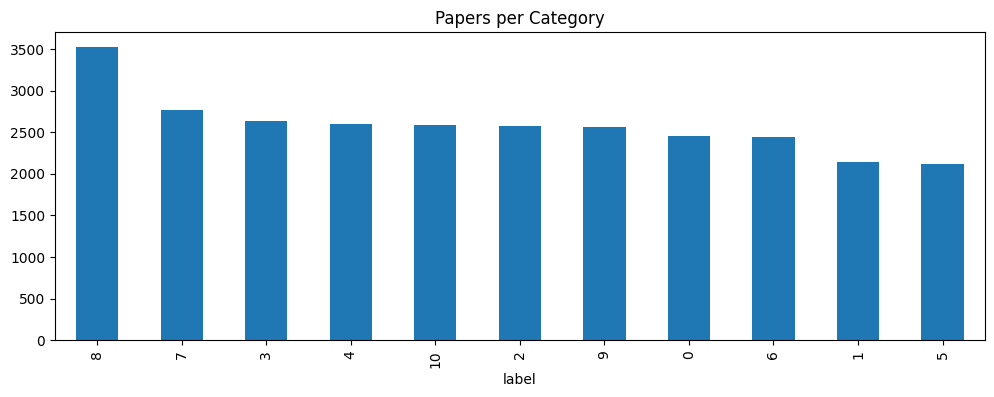

In [5]:
print(f"Number of categories: {df['label'].nunique()}")
df['label'].value_counts().plot(kind='bar', figsize=(12, 4), title='Papers per Category')

In [6]:
for i in range(5):
    print(f"\n--- Paper {i} ---")
    print(f"Label: {df['text'][i][:100]}...")
    print()



--- Paper 0 ---
Label: Constrained Submodular Maximization via a
Non-symmetric Technique

arXiv:1611.03253v1 [cs.DS] 10 Nov...


--- Paper 1 ---
Label: Self Organizing Maps Whose Topologies Can Be Learned With
Adaptive Binary Search Trees Using Conditi...


--- Paper 2 ---
Label: Robust Satisfaction of Temporal Logic Specifications via Reinforcement
Learning

arXiv:1510.06460v1 ...


--- Paper 3 ---
Label: BATCHED QR AND SVD ALGORITHMS ON GPUS WITH APPLICATIONS
IN HIERARCHICAL MATRIX COMPRESSION

arXiv:17...


--- Paper 4 ---
Label: Analytical and simplified models for dynamic analysis
of short skew bridges under moving loads

arXi...



In [7]:
df['text_length'] = df['text'].apply(len)
df['text_length'].describe()

count    2.838800e+04
mean     5.645798e+04
std      5.005934e+04
min      2.852000e+03
25%      3.201875e+04
50%      4.643500e+04
75%      6.831200e+04
max      2.553775e+06
Name: text_length, dtype: float64

In [8]:
print(df['label'].value_counts().sort_index())

label
0     2456
1     2137
2     2569
3     2631
4     2599
5     2117
6     2443
7     2768
8     3527
9     2560
10    2581
Name: count, dtype: int64


In [9]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['math.AC', 'cs.CV', 'cs.AI', 'cs.SY', 'math.GR', 'cs.CE', 'cs.PL', 'cs.IT', 'cs.DS', 'cs.NE', 'math.ST'])}


In [10]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 42.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 42.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Grab the text and labels from train and test splits
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

# Turn the text into numbers (TF-IDF)
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english")
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

print("Data ready! Training model...")

Data ready! Training model...


In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, train_labels)

predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(test_labels, predictions):.2%}")
print()
print(classification_report(test_labels, predictions))

Accuracy: 84.40%

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       212
           1       0.79      0.81      0.80       194
           2       0.70      0.56      0.62       205
           3       0.86      0.90      0.88       233
           4       0.94      0.95      0.95       234
           5       0.79      0.75      0.77       196
           6       0.88      0.95      0.91       241
           7       0.86      0.84      0.85       236
           8       0.88      0.90      0.89       318
           9       0.74      0.74      0.74       219
          10       0.82      0.87      0.84       212

    accuracy                           0.84      2500
   macro avg       0.84      0.84      0.84      2500
weighted avg       0.84      0.84      0.84      2500

